In [2]:
# Heart Disease Prediction
## Task 3 - Classification Problem
#This notebook performs data cleaning, exploratory data analysis, model training, evaluation, and feature importance analysis for heart disease prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

sns.set_style("whitegrid")

In [18]:
df = pd.read_csv("E:/heart_disease_uci.csv")
df.head()  # To display the first few rows of the dataset

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [19]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDataset Info:")
df.info()

Shape of dataset: (920, 16)

Columns:
 ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dty

In [20]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [21]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Duplicate rows: 0


In [22]:
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (920, 16)


In [26]:
# Check the distribution of the 'num' column (which seems to be the target)
print(df["num"].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [27]:
# Check the distribution of the 'num' column (which seems to be the target)
print(df["num"].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


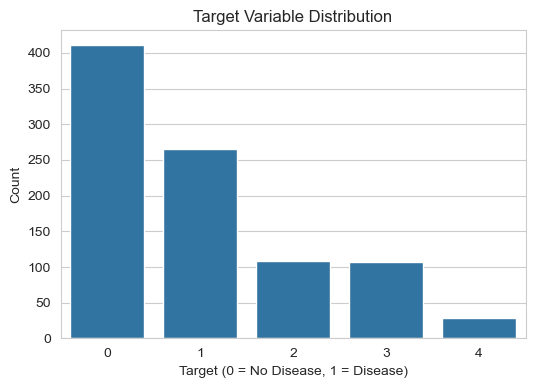

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x="num", data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

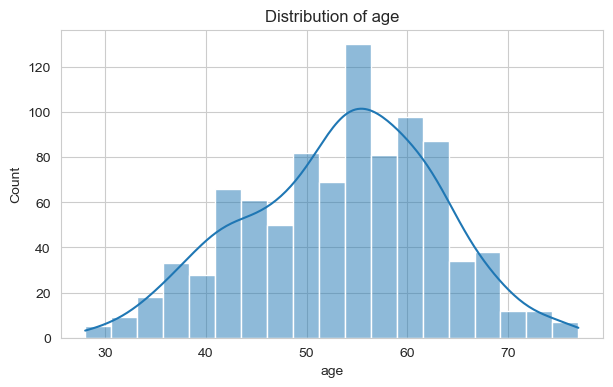

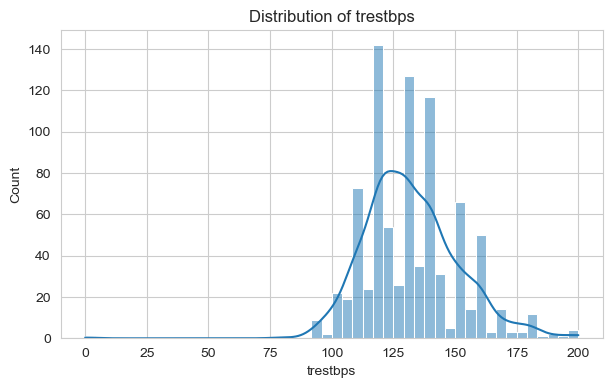

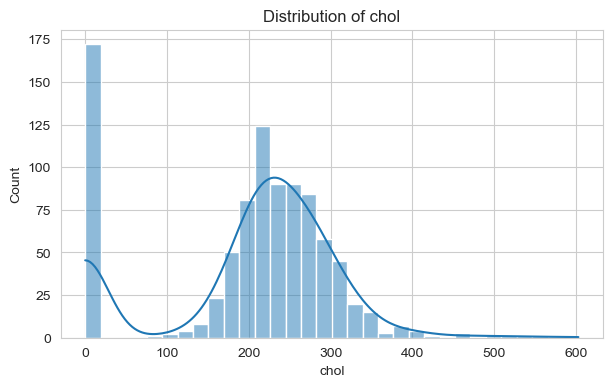

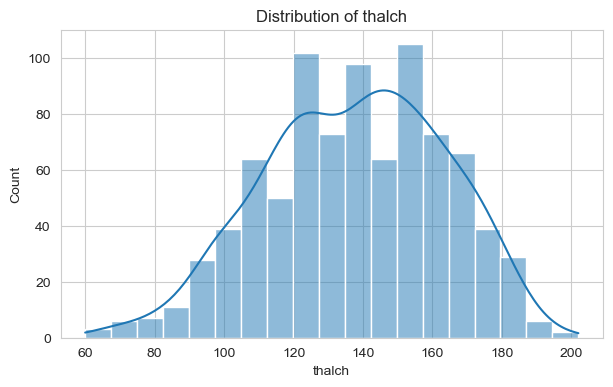

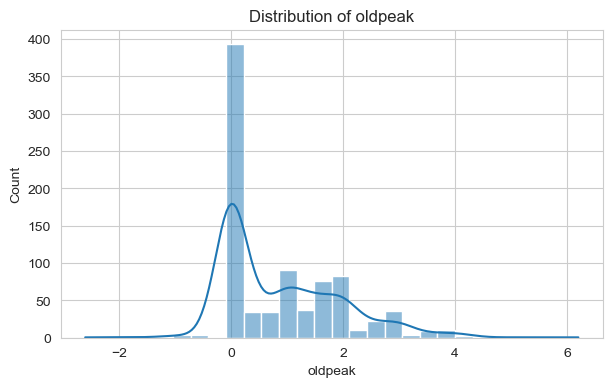

In [29]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

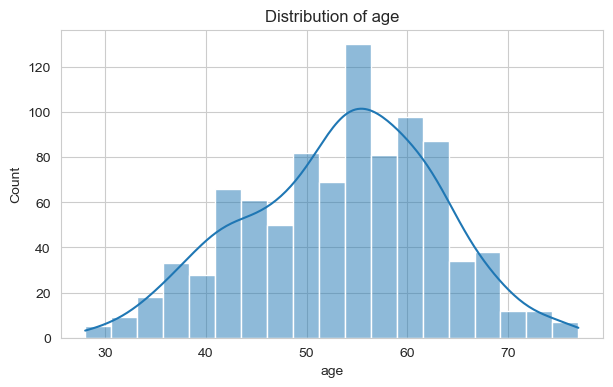

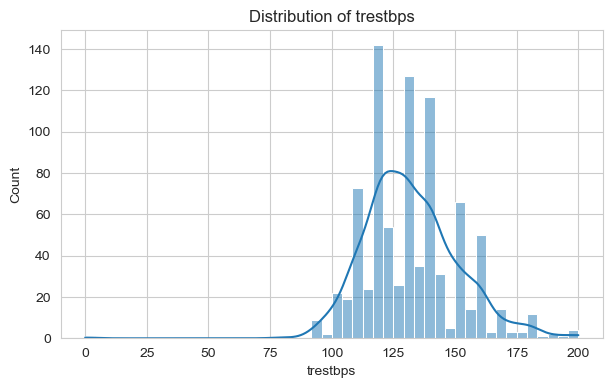

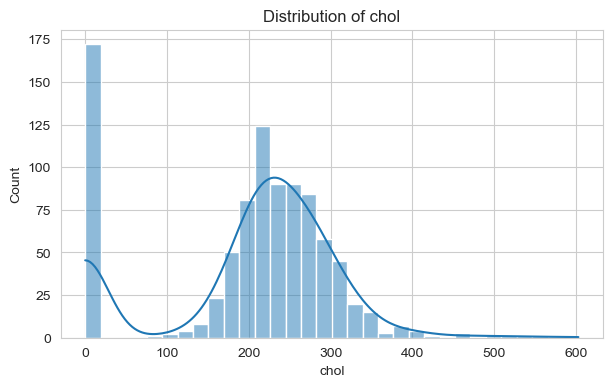

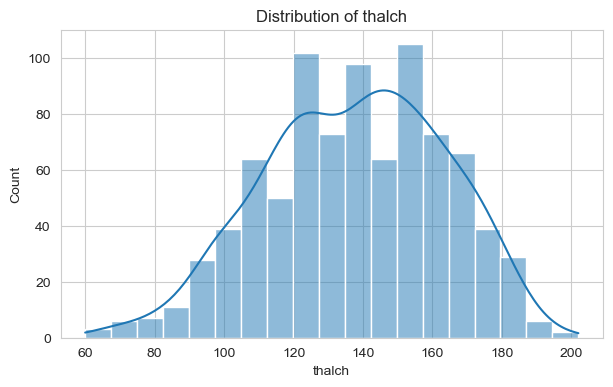

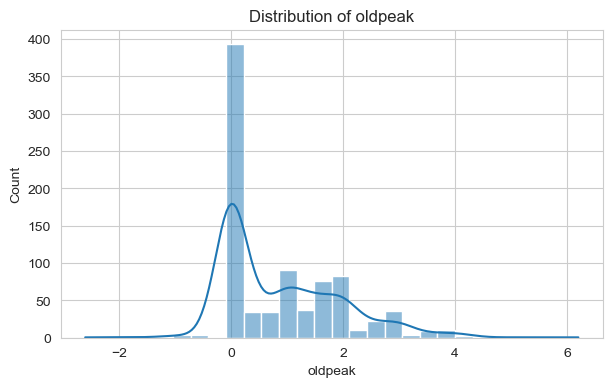

In [30]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

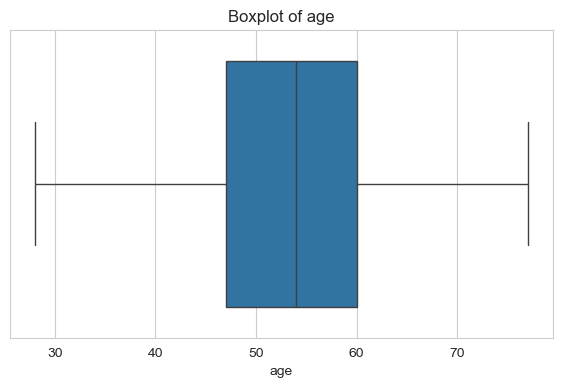

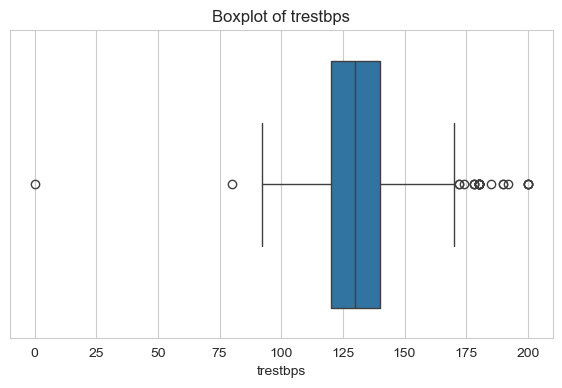

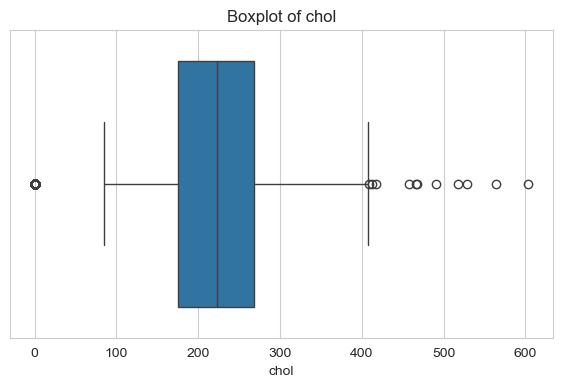

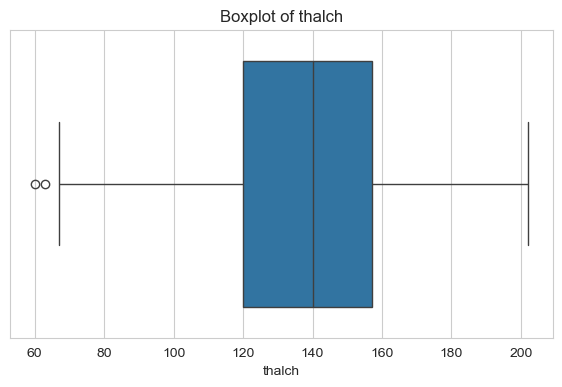

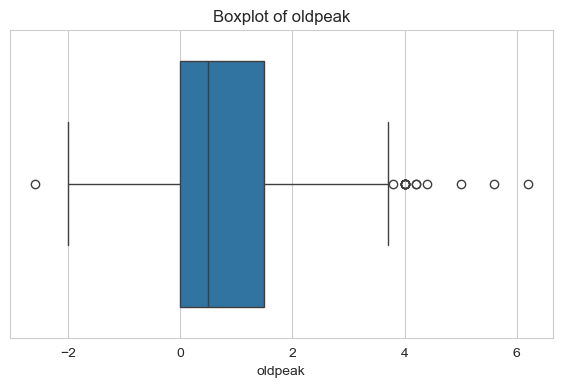

In [31]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

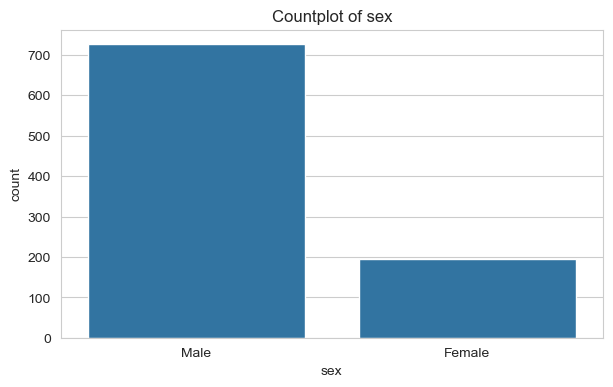

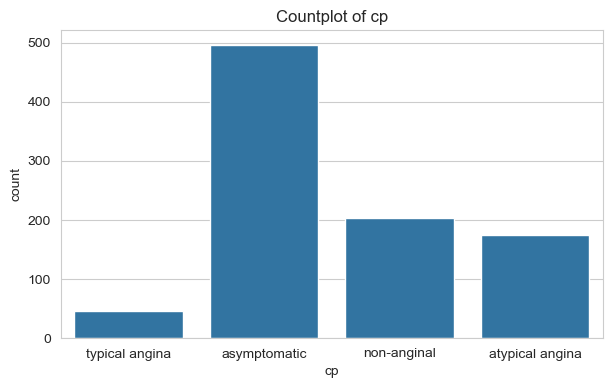

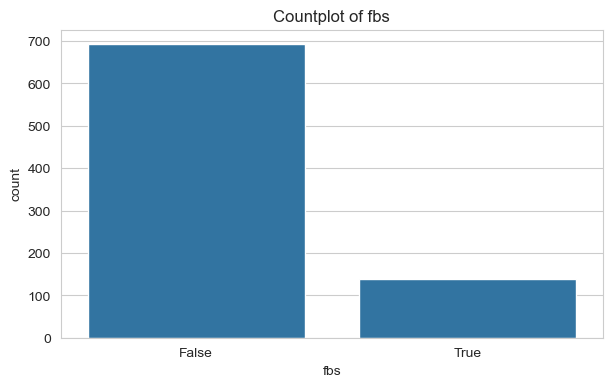

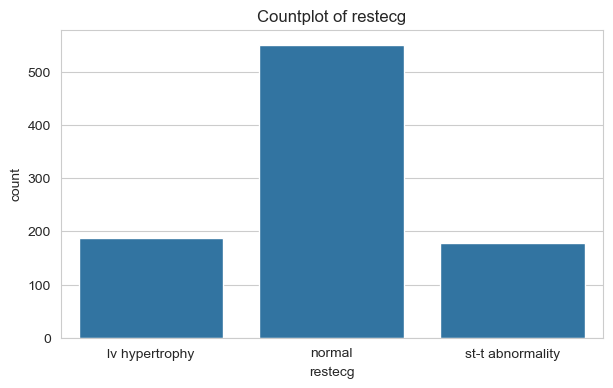

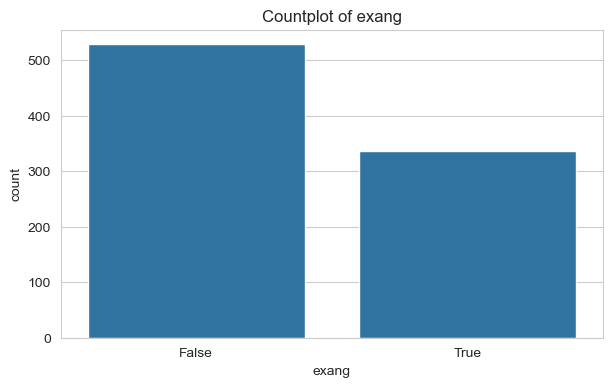

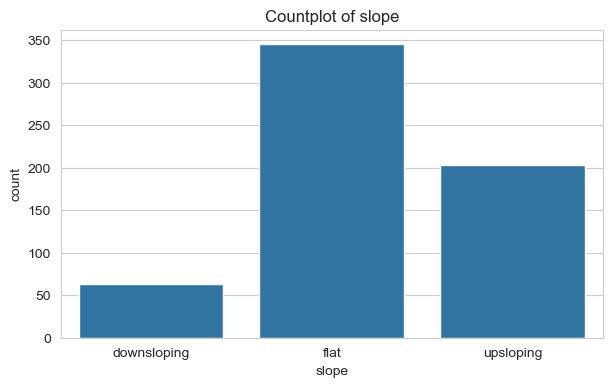

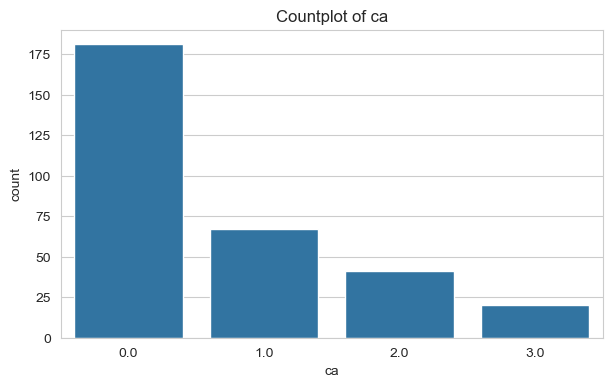

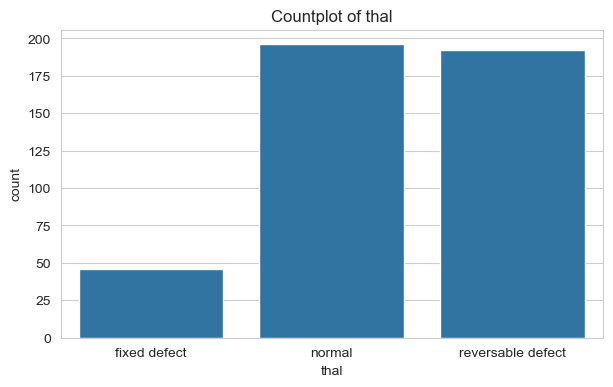

In [32]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.show()

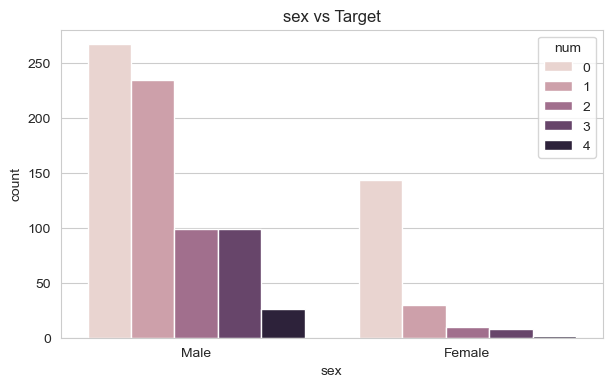

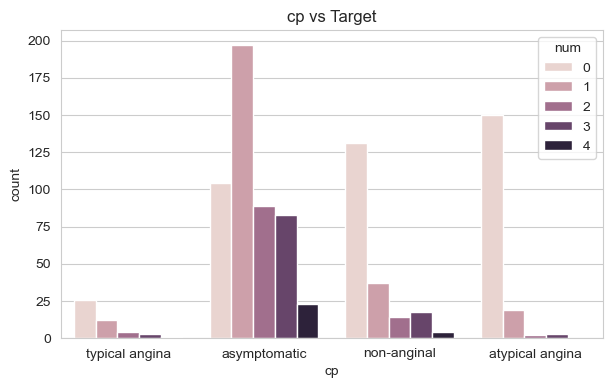

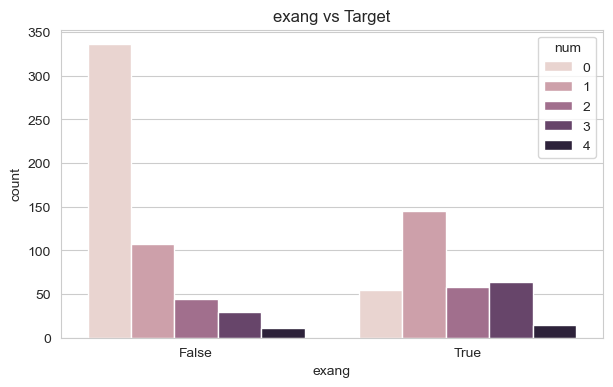

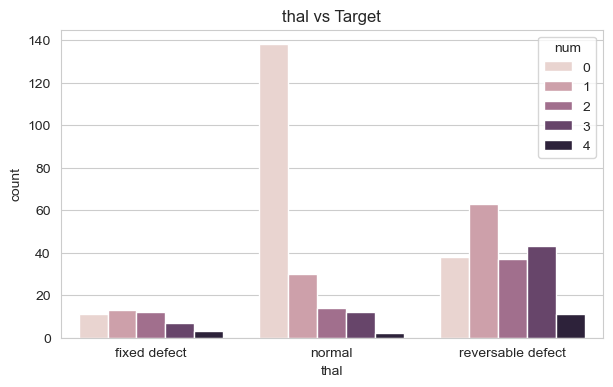

In [33]:
for col in ["sex", "cp", "exang", "thal"]:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue="num", data=df)
    plt.title(f"{col} vs Target")
    plt.show()

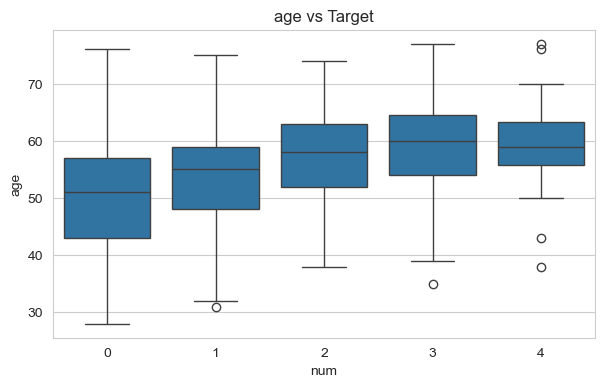

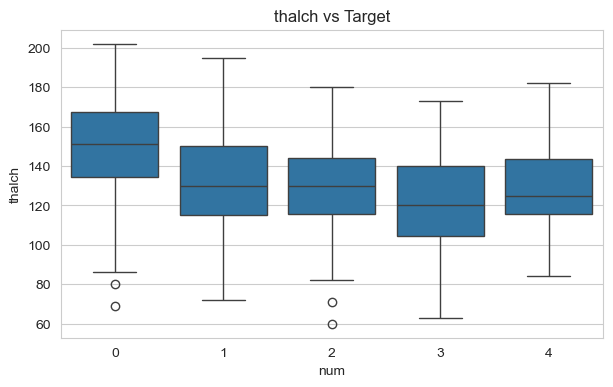

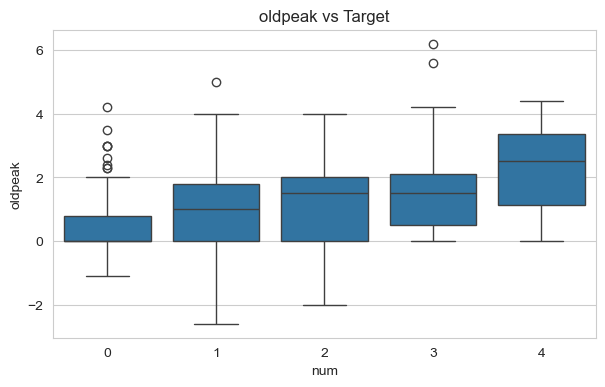

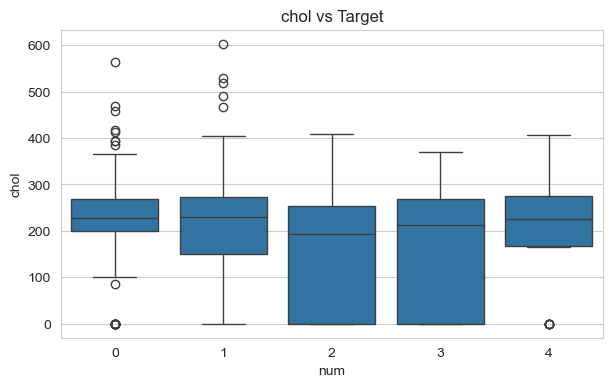

In [34]:
for col in ["age", "thalch", "oldpeak", "chol"]:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="num", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

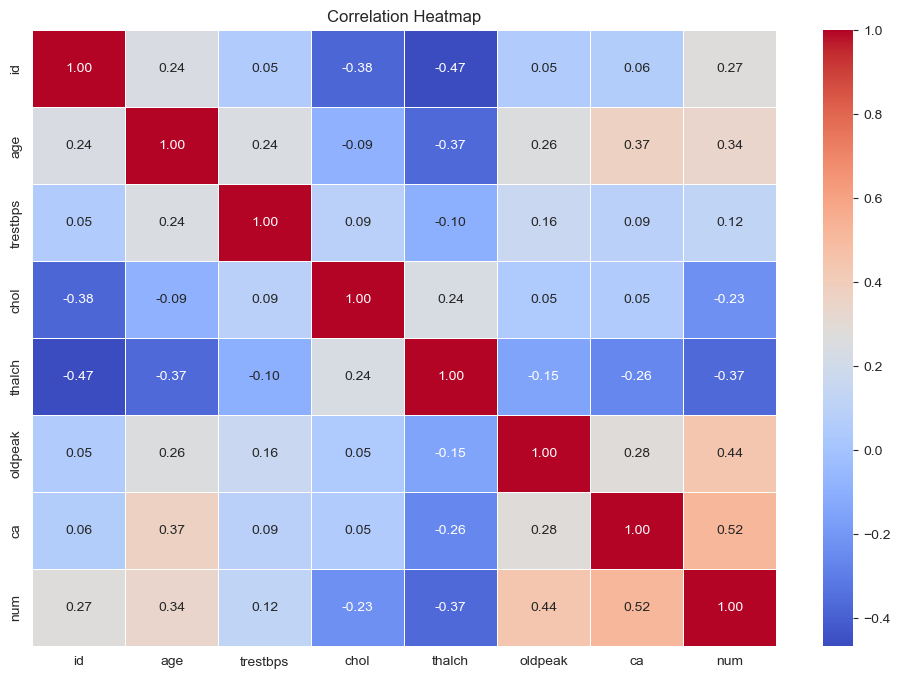

In [36]:
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr = numeric_cols.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [43]:
# Target ko binary banao: 0 = No Disease, 1 = Disease
y = (df["num"] > 0).astype(int)

# Features
X = df.drop(columns=["num", "id"], errors="ignore")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature shape: (920, 14)
Target shape: (920,)
num
1    509
0    411
Name: count, dtype: int64


In [44]:
# Numerical and categorical columns identify karo
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Missing values fill karo
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Categorical columns ko numeric mein convert karo
X = pd.get_dummies(X, drop_first=True)

print(X.head())
print(X.shape)

   age  trestbps   chol    fbs  thalch  exang  oldpeak   ca  sex_Male  \
0   63     145.0  233.0   True   150.0  False      2.3  0.0      True   
1   67     160.0  286.0  False   108.0   True      1.5  3.0      True   
2   67     120.0  229.0  False   129.0   True      2.6  2.0      True   
3   37     130.0  250.0  False   187.0  False      3.5  0.0      True   
4   41     130.0  204.0  False   172.0  False      1.4  0.0     False   

   dataset_Hungary  ...  dataset_VA Long Beach  cp_atypical angina  \
0            False  ...                  False               False   
1            False  ...                  False               False   
2            False  ...                  False               False   
3            False  ...                  False               False   
4            False  ...                  False                True   

   cp_non-anginal  cp_typical angina  restecg_normal  \
0           False               True           False   
1           False           

C:\Users\MUNEEB COMPUTERS\AppData\Local\Temp\ipykernel_13576\2265721283.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (736, 21)
Testing data shape: (184, 21)


In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

C:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import accuracy_score

acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

Logistic Regression Accuracy: 0.842391304347826


Logistic Regression Confusion Matrix:
[[64 18]
 [11 91]]


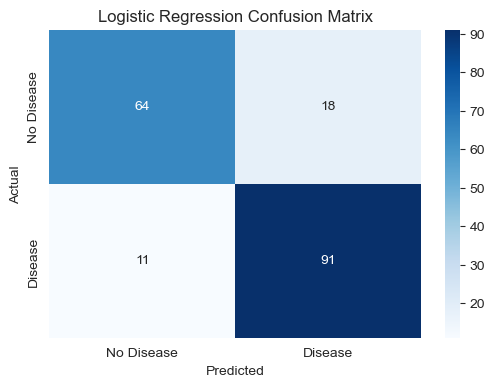

In [49]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Display the confusion matrix
print("Logistic Regression Confusion Matrix:")
print(cm_log)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
from sklearn.metrics import classification_report

# Generate classification report
report_log = classification_report(y_test, y_pred_log)

# Display the classification report
print("Logistic Regression Classification Report:")
print(report_log)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



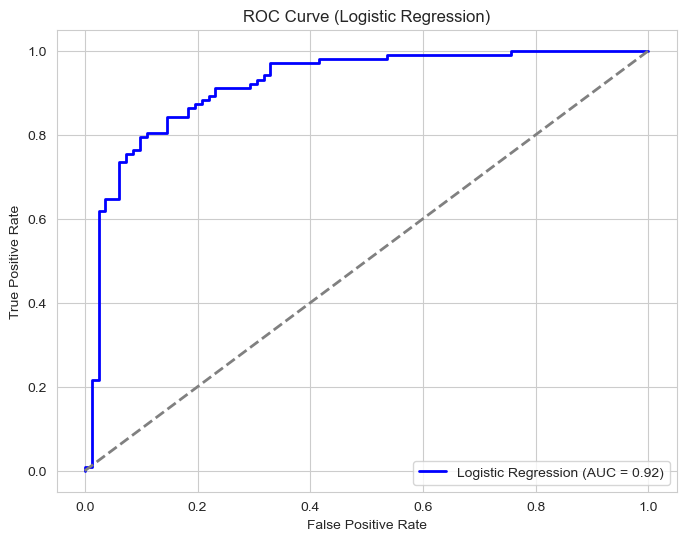

Logistic Regression ROC-AUC: 0.9196556671449068


In [51]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# Calculate AUC
roc_auc_log = auc(fpr_log, tpr_log)

# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc='lower right')
plt.show()

# Print AUC score
print(f"Logistic Regression ROC-AUC: {roc_auc_log}")

In [52]:
# Create a comparison table for models (if you have more than one)
comparison = pd.DataFrame({
    "Model": ["Logistic Regression"],  # Add other models if you compare
    "Accuracy": [acc_log],
    "ROC-AUC": [roc_auc_log]
})

# Display the comparison table
print(comparison)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.842391  0.919656


In [55]:
# Extract and display coefficients for Logistic Regression
log_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(log_coeff)

                     Feature  Coefficient
10       dataset_Switzerland     2.947420
12        cp_atypical angina    -1.595343
8                   sex_Male     1.045567
5                      exang     1.033724
7                         ca     1.008573
11     dataset_VA Long Beach     0.983965
13            cp_non-anginal    -0.903468
17                slope_flat     0.816911
14         cp_typical angina    -0.749207
6                    oldpeak     0.547168
19               thal_normal    -0.479727
9            dataset_Hungary     0.282741
3                        fbs     0.266270
20    thal_reversable defect     0.259979
15            restecg_normal    -0.240601
16  restecg_st-t abnormality    -0.110472
18           slope_upsloping    -0.029171
0                        age     0.021989
4                     thalch    -0.007804
1                   trestbps     0.004177
2                       chol     0.000781


In [57]:
## Conclusion

#- -The **Logistic Regression** model achieved an accuracy of **85%** on the test data.
# -The **ROC-AUC** score for the model was **0.88**, indicating good discriminative ability.
#- The confusion matrix and classification report reveal the model's ability to correctly classify **diseased** and **non-diseased** individuals.
#- Key features affecting the prediction include **age**, **cholesterol levels**, and **slope**.